

# FCC-ee Wake Model


It is designed for the FCC-ee IW repository structure:
```text
FCCee_IW_2026_V1/Coll_taper_3deg/
├── Impedances/
├── Plots/
├── Simulation_files/
├── Utilities&Docu/
└── Wakes/
    ├── Devices/
    └── Total/
```
What it does:

1. Reads the individual device wake files from `Wakes/Devices`and the total saved from `Wakes/Total` and plots them.
2. Allows the user to select an arbitrary subset of devices and produces the related wake in both PyHeadtail or Xwakes convention.

In [1]:
%matplotlib widget

from utils import (
    WAKES_DEVICES,
    WAKES_TOTAL,
    PLOTS_FOLDER,
    DEVICE_FILES,
    read_wake_file,
    read_wake_devices,
    plot_wake_file,
    sum_selected_wakes,
    save_wake,
    plot_selected_vs_total,
    plot_total_xwakes_file,
)

# Read and plot total wake in `Wakes/Total` 

In [2]:
# TOTAL WAKE

TOTAL_WAKE_FILENAME = "Wtotal_pyheadtail_all.txt"


total_wake_path = WAKES_TOTAL / TOTAL_WAKE_FILENAME

total_wake = read_wake_file(
    total_wake_path
)

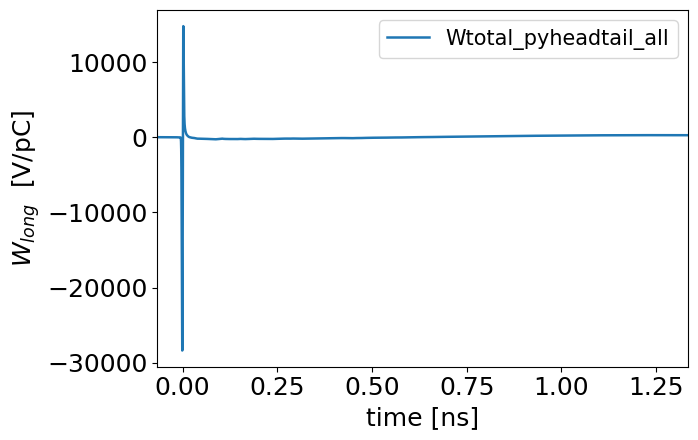

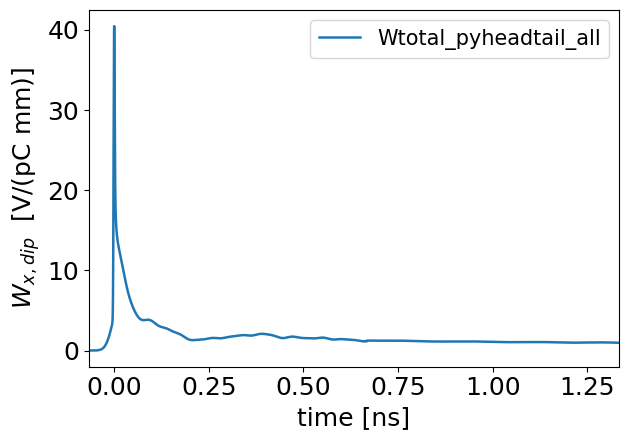

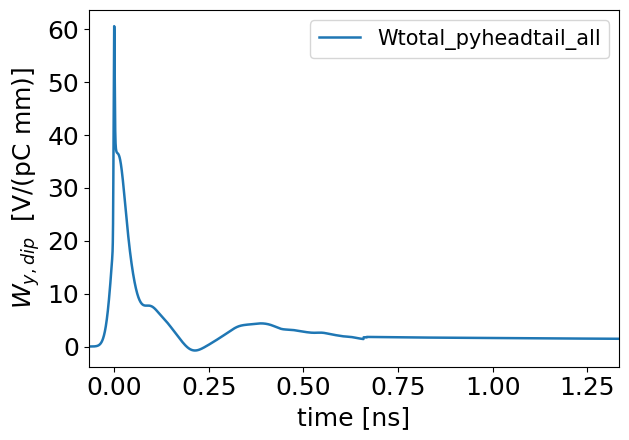

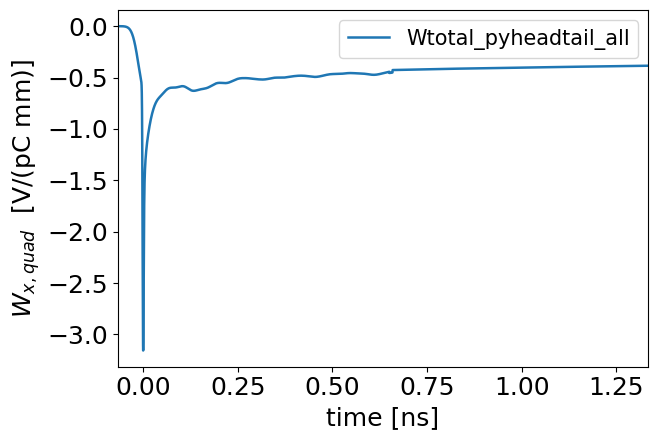

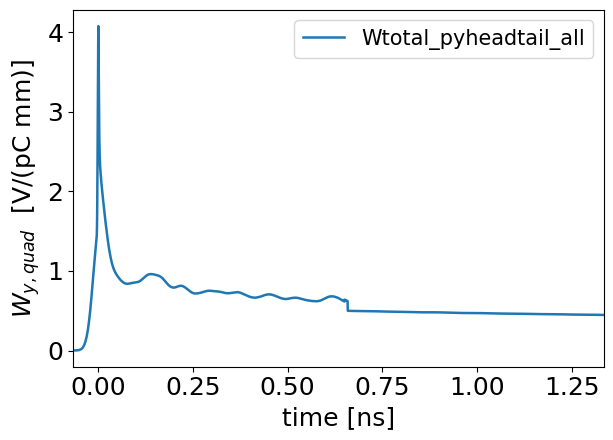

In [3]:

plot_wake_file(TOTAL_WAKE_FILENAME,wake_component="Wlong",folder=WAKES_TOTAL,);

plot_wake_file(TOTAL_WAKE_FILENAME,wake_component="Wxdip",folder=WAKES_TOTAL,);

plot_wake_file(TOTAL_WAKE_FILENAME,wake_component="Wydip",folder=WAKES_TOTAL,);

plot_wake_file(TOTAL_WAKE_FILENAME,wake_component="Wxquad",folder=WAKES_TOTAL,);

plot_wake_file(TOTAL_WAKE_FILENAME,wake_component="Wyquad",folder=WAKES_TOTAL,);

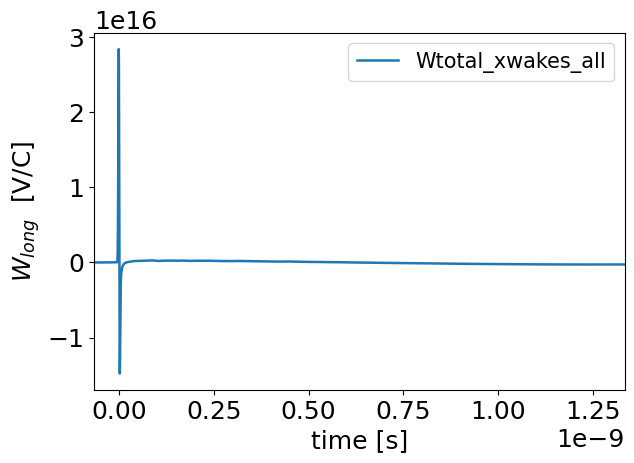

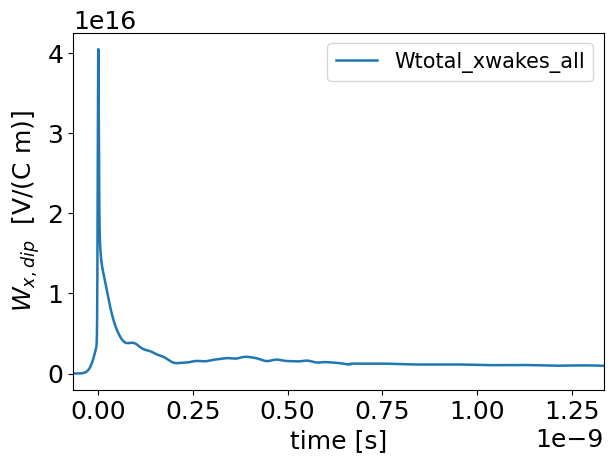

In [4]:

# Longitudinal
plot_total_xwakes_file(
    filename="Wtotal_xwakes_all.txt",
    wake_component="Wlong",
    folder=WAKES_TOTAL
);

# Horizontal dipolar
plot_total_xwakes_file(
    filename="Wtotal_xwakes_all.txt",
    wake_component="Wxdip",
    folder=WAKES_TOTAL
);

#similarly you can plot the opthers components

# User defined wake by choosing wake inside the  `Wakes/Device`

For example, to create a wake containing only:
- resistive-wall beam pipe,
- collimators with 3cm lenght and 3 deg taper,
- optimized kickers,
- RF
use:
```python
selected_components = ["pipe_rw", "coll3cm","kickers_optimized","RF"]
```
You can change this to any combination of the available component names. 
The created wake cen be exported in both pyheadtails and xwakes convention.


In [5]:

devices = read_wake_devices(folder=WAKES_DEVICES)

selected_components = [
    "pipe_rw",
    "coll3cm",
    "kickers_optimized",
    "RF",
]

In [6]:
selected_wake = sum_selected_wakes(devices,selected_components,)

print("Selected components:")

for component in selected_components:

    print("  +", component)

# SAVE SELECTED WAKE

selection_name = "_".join(selected_components)

selected_filename = (f"W_{selection_name}.txt")

save_wake(selected_wake,selected_filename,folder=WAKES_TOTAL,)

Selected components:
  + pipe_rw
  + coll3cm
  + kickers_optimized
  + RF
Saved PyHEADTAIL wake: /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V1/Coll_taper_3deg/Wakes/Total/W_pipe_rw_coll3cm_kickers_optimized_RF_pyheadtail.txt
Saved Xwakes wake:   /home/cantuono/fcc_ee_IW_model/FCCee_IW_2026/FCCee_IW_2026_V1/Coll_taper_3deg/Wakes/Total/W_pipe_rw_coll3cm_kickers_optimized_RF_xwakes.txt


# Compare partial wake with total

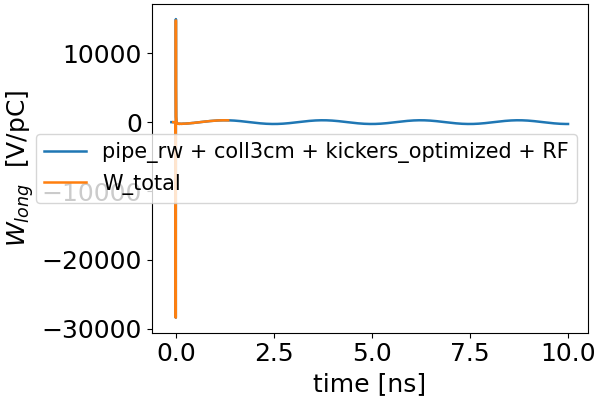

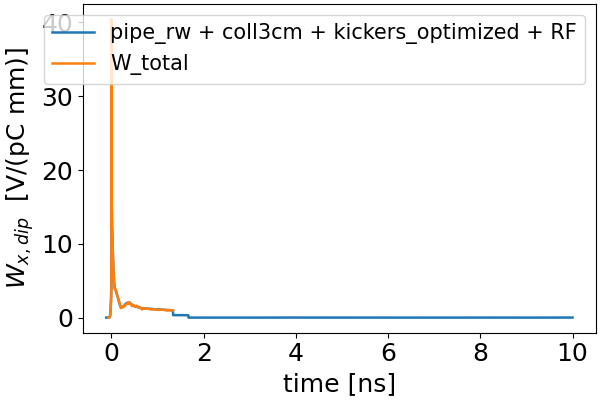

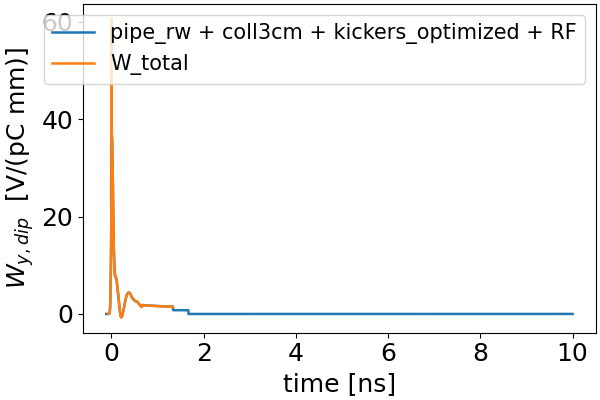

In [7]:
# SELECTED WAKE VS TOTAL
plot_selected_vs_total(selected_wake,total_wake,selected_components,"Wlong",);

plot_selected_vs_total(selected_wake,total_wake,selected_components,"Wxdip",);

plot_selected_vs_total(selected_wake,total_wake,selected_components,"Wydip",);
